In [1]:
from langgraph.graph import StateGraph,START,END

from typing import TypedDict

In [2]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int
    equation:str
    discriminant:float
    result:str

In [ ]:
a=QuadState({"a":2,"b":0,"c":7.8,"discriminant":9})

In [14]:
a

{'a': 2, 'b': 2.2, 'c': 7.8, 'discriminant': 9}

In [4]:
def show_equation(state:QuadState):
    equation=f"{state["a"]}x2+{state["b"]}x+{state["c"]}"
   
    return {"equation":equation}

In [21]:
def calculate_discriminant(state:QuadState):
    discriminant=state["b"]**2-4*state["a"]*state["c"]
    return {"discriminant":discriminant}

In [11]:
def real_root(state:QuadState):
        return {"result":"real root "}

In [12]:
def repeated_root(state:QuadState):
        return {"result":"repeated root "}

In [ ]:
def no_real_root(state:QuadState):
        return {"result":"no_real root"}

In [14]:
def check_condition(state:QuadState):
    if state['discriminant']>0:
        return "real_root"
    elif state['discriminant']==0:
        return "repeated_root"
    else:
        return "no_real_root"

In [22]:
graph=StateGraph(QuadState)

graph.add_node("show_equation",show_equation)
graph.add_node("calculate_discriminant",calculate_discriminant)
graph.add_node("real_root",real_root)
graph.add_node("repeated_root",repeated_root)
graph.add_node("no_real_root",no_real_root)


graph.add_edge(START,"show_equation")
graph.add_edge("show_equation","calculate_discriminant")
graph.add_conditional_edges("calculate_discriminant",check_condition)
graph.add_edge("no_real_root",END)
graph.add_edge("real_root",END)
graph.add_edge("repeated_root",END)

In [23]:
workflow=graph.compile()

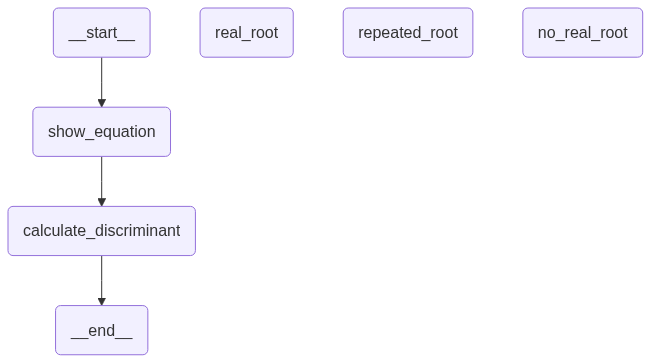

In [24]:
workflow

In [29]:
initial_state={"a":2,"b":0,"c":1}

In [30]:
workflow.invoke(initial_state)

{'a': 2,
 'b': 0,
 'c': 1,
 'equation': '2x2+0x+1',
 'discriminant': -8,
 'result': 'no_real root '}